# DGIM Algorithm — Sliding Window 1-Counting

## Learning Objectives

1. **Explain** the stream model and the sliding window constraint
2. **Define** DGIM buckets and their two invariants
3. **Derive** the merge rule and prove it maintains the invariants
4. **Analyse** space complexity: $O(\log^2 N)$ bits, and error bound: at most 50%
5. **Implement** the DGIM stream processor


## Problem Statement

### Stream Model

Data arrives as an infinite stream. We can only maintain a small summary in memory and cannot go back to re-read old data. The **sliding window** model restricts queries to the last $N$ elements.

**Query:** How many 1-bits appeared in the last $N$ positions of a binary stream?

**Naïve approach:** store the last $N$ bits explicitly. Space = $O(N)$. For $N = 10^9$ this is 125 MB.

**DGIM target:** answer with at most 50% relative error using $O(\log^2 N)$ bits.

### Why Approximation?

For many stream analytics applications (click-through estimation, network monitoring), a 50% error bound is acceptable if it means using $O(\log^2 N)$ instead of $O(N)$ space — a factor of $\log^2 N / N$ reduction.


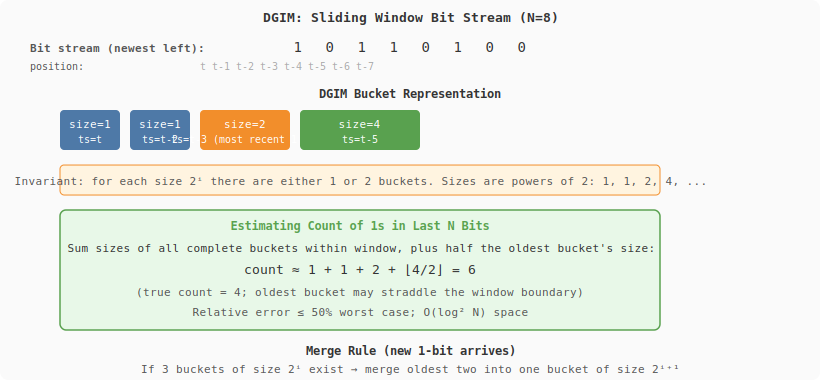

In [1]:
from IPython.display import SVG, display

svg = '''
<svg xmlns="http://www.w3.org/2000/svg" width="820" height="380" font-family="monospace" font-size="12">
  <rect width="820" height="380" fill="#fafafa" rx="8"/>

  <!-- title -->
  <text x="410" y="22" text-anchor="middle" fill="#333" font-size="13" font-weight="bold">DGIM: Sliding Window Bit Stream (N=8)</text>

  <!-- ── Bit stream ── -->
  <text x="30" y="52" fill="#555" font-size="11" font-weight="bold">Bit stream (newest left):</text>
  <text x="410" y="52" text-anchor="middle" fill="#333" font-size="14" letter-spacing="8">1  0  1  1  0  1  0  0</text>
  <text x="30"  y="70" fill="#555" font-size="10">position:</text>
  <text x="200" y="70" fill="#aaa" font-size="10">t  t-1  t-2  t-3  t-4  t-5  t-6  t-7</text>

  <!-- ── Bucket structure ── -->
  <text x="410" y="98" text-anchor="middle" fill="#333" font-size="12" font-weight="bold">DGIM Bucket Representation</text>

  <!-- Bucket 1: size 1, timestamp t -->
  <rect x="60"  y="110" width="60" height="40" rx="4" fill="#4e79a7"/>
  <text x="90"  y="128" text-anchor="middle" fill="white" font-size="11">size=1</text>
  <text x="90"  y="143" text-anchor="middle" fill="white" font-size="10">ts=t</text>

  <!-- Bucket 2: size 1, timestamp t-2 -->
  <rect x="130" y="110" width="60" height="40" rx="4" fill="#4e79a7"/>
  <text x="160" y="128" text-anchor="middle" fill="white" font-size="11">size=1</text>
  <text x="160" y="143" text-anchor="middle" fill="white" font-size="10">ts=t-2</text>

  <!-- Bucket 3: size 2, timestamp t-3 -->
  <rect x="200" y="110" width="90" height="40" rx="4" fill="#f28e2b"/>
  <text x="245" y="128" text-anchor="middle" fill="white" font-size="11">size=2</text>
  <text x="245" y="143" text-anchor="middle" fill="white" font-size="10">ts=t-3 (most recent 1 in)</text>

  <!-- Bucket 4: size 4, timestamp t-5 -->
  <rect x="300" y="110" width="120" height="40" rx="4" fill="#59a14f"/>
  <text x="360" y="128" text-anchor="middle" fill="white" font-size="11">size=4</text>
  <text x="360" y="143" text-anchor="middle" fill="white" font-size="10">ts=t-5</text>

  <!-- invariant -->
  <rect x="60" y="165" width="600" height="30" rx="4" fill="#fff4e0" stroke="#f28e2b" stroke-width="1"/>
  <text x="360" y="185" text-anchor="middle" fill="#555" font-size="11">Invariant: for each size 2ⁱ there are either 1 or 2 buckets. Sizes are powers of 2: 1, 1, 2, 4, ...</text>

  <!-- ── Count estimate ── -->
  <rect x="60" y="210" width="600" height="120" rx="6" fill="#e8f8e8" stroke="#59a14f" stroke-width="1.5"/>
  <text x="360" y="230" text-anchor="middle" fill="#59a14f" font-size="12" font-weight="bold">Estimating Count of 1s in Last N Bits</text>
  <text x="360" y="252" text-anchor="middle" fill="#333" font-size="11">Sum sizes of all complete buckets within window, plus half the oldest bucket's size:</text>
  <text x="360" y="274" text-anchor="middle" fill="#333" font-size="13">count ≈ 1 + 1 + 2 + ⌊4/2⌋  =  6</text>
  <text x="360" y="296" text-anchor="middle" fill="#555" font-size="11">(true count = 4; oldest bucket may straddle the window boundary)</text>
  <text x="360" y="316" text-anchor="middle" fill="#555" font-size="11">Relative error ≤ 50% worst case; O(log² N) space</text>

  <!-- ── New bit arrives: merge rule ── -->
  <text x="410" y="355" text-anchor="middle" fill="#333" font-size="12" font-weight="bold">Merge Rule (new 1-bit arrives)</text>
  <text x="410" y="373" text-anchor="middle" fill="#555" font-size="11">If 3 buckets of size 2ⁱ exist → merge oldest two into one bucket of size 2ⁱ⁺¹</text>
</svg>
'''

display(SVG(svg))


## DGIM Bucket Structure

### Buckets

A *bucket* $(size, timestamp)$ represents a contiguous group of positions in the stream:
- $size = 2^i$ for some non-negative integer $i$ (bucket sizes are powers of 2)
- $timestamp$ = the position of the **most recent 1** covered by this bucket

### Two Invariants

**Invariant 1:** The sizes of buckets form a non-decreasing sequence from newest to oldest.

**Invariant 2:** For each size $2^i$, there are either exactly 1 or exactly 2 buckets of that size.

These invariants guarantee:
- The total number of buckets is $O(\log N)$ (at most 2 per size, and sizes are $1, 2, 4, \ldots, N$)
- Actually $O(\log^2 N)$ bits to store all (size, timestamp) pairs

### Why Sizes Are Powers of 2?

If sizes were arbitrary, maintaining the compact representation would require arbitrary-precision merging. Powers of 2 let us detect "overflow" (3 buckets of same size) and merge with a simple halving.

## Estimation

To count 1s in the last $N$ positions:

1. Sum the sizes of all buckets whose timestamp is within the window
2. Subtract half the size of the oldest such bucket (it may straddle the window boundary)

$$\hat{c} = \sum_{\text{bucket } b \text{ in window}} \text{size}(b) - \lfloor \text{size}(\text{oldest}) / 2 \rfloor$$

**Error bound:** The oldest bucket contributes at most $\text{size}(\text{oldest})/2$ to the error, and $\text{size}(\text{oldest}) \leq$ true count. So relative error $\leq 50\%$.


## Merge Rule (When New 1 Arrives)

1. Add a new bucket $(1, t)$ at the front
2. While there exist 3 buckets of size $2^i$: merge the two **oldest** into one bucket of size $2^{i+1}$ at their oldest timestamp
3. Remove any bucket whose timestamp is $< t - N + 1$ (outside window)

This maintains both invariants and takes $O(\log N)$ time per new bit.


In [2]:
from collections import deque


def dgim_query(buckets, N):
    """
    Estimate the count of 1s in the last N positions from DGIM bucket list.
    buckets : deque of (size, timestamp) sorted newest-first
    N       : window size
    Returns : estimated count
    """
    if not buckets:
        return 0
    newest_ts = buckets[0][1]
    oldest_allowed = newest_ts - N + 1

    total = 0
    last_size = 0
    for size, ts in buckets:
        if ts < oldest_allowed:
            break
        last_size = size
        total += size

    # The oldest bucket in window may partially lie outside → credit only half
    return total - last_size // 2


class DGIMStream:
    """DGIM sliding window counter for a binary stream."""
    ""

    def __init__(self, N):
        self.N = N
        self.t = 0                 # current timestamp
        self.buckets = deque()     # (size, timestamp), newest first

    def process(self, bit):
        self.t += 1

        # Remove buckets that have slid outside the window
        while self.buckets and self.buckets[-1][1] < self.t - self.N:
            self.buckets.pop()

        if bit == 0:
            return

        # Add a new bucket of size 1 at the front
        self.buckets.appendleft((1, self.t))

        # Merge: if 3 or more buckets of the same size exist, merge oldest two
        self._merge()

    def _merge(self):
        changed = True
        while changed:
            changed = False
            size_count = {}
            for size, ts in self.buckets:
                size_count[size] = size_count.get(size, 0) + 1

            for size, count in size_count.items():
                if count >= 3:
                    # Find and remove the two oldest buckets of this size, replace with one of size*2
                    new_buckets = deque()
                    merged = 0
                    for b_size, b_ts in reversed(self.buckets):
                        if b_size == size and merged < 2:
                            merged += 1
                            if merged == 2:
                                new_buckets.appendleft((size * 2, b_ts))
                            # else drop it (will be absorbed into merged bucket)
                        else:
                            new_buckets.appendleft((b_size, b_ts))
                    self.buckets = new_buckets
                    changed = True
                    break

    def query(self):
        return dgim_query(self.buckets, self.N)

    def n_buckets(self):
        return len(self.buckets)


# ── Demo ──────────────────────────────────────────────────────────────────────
import random
random.seed(0)

N = 64
stream = DGIMStream(N)
bits = [random.randint(0, 1) for _ in range(200)]

for bit in bits:
    stream.process(bit)

window = bits[-N:]
true_count = sum(window)
est_count  = stream.query()
error_pct  = abs(est_count - true_count) / max(true_count, 1) * 100

print(f"Window size N = {N}")
print(f"True count of 1s  : {true_count}")
print(f"DGIM estimate     : {est_count}")
print(f"Relative error    : {error_pct:.1f}%")
print(f"Number of buckets : {stream.n_buckets()} (O(log²N) = O({int(int(N**0.5).bit_length()**2)}))")


Window size N = 64
True count of 1s  : 36
DGIM estimate     : 40
Relative error    : 11.1%
Number of buckets : 7 (O(log²N) = O(16))
